In [1]:
import pandas as pd
df = pd.read_csv("Tehri_Landslide_Data.csv")


In [10]:
df.label.value_counts()

label
1    2591
0    2591
Name: count, dtype: int64

In [5]:
corr_mat = df.drop(columns=["x", "y", "landslide_id", "TRI", "BSI", "label"]).corr()

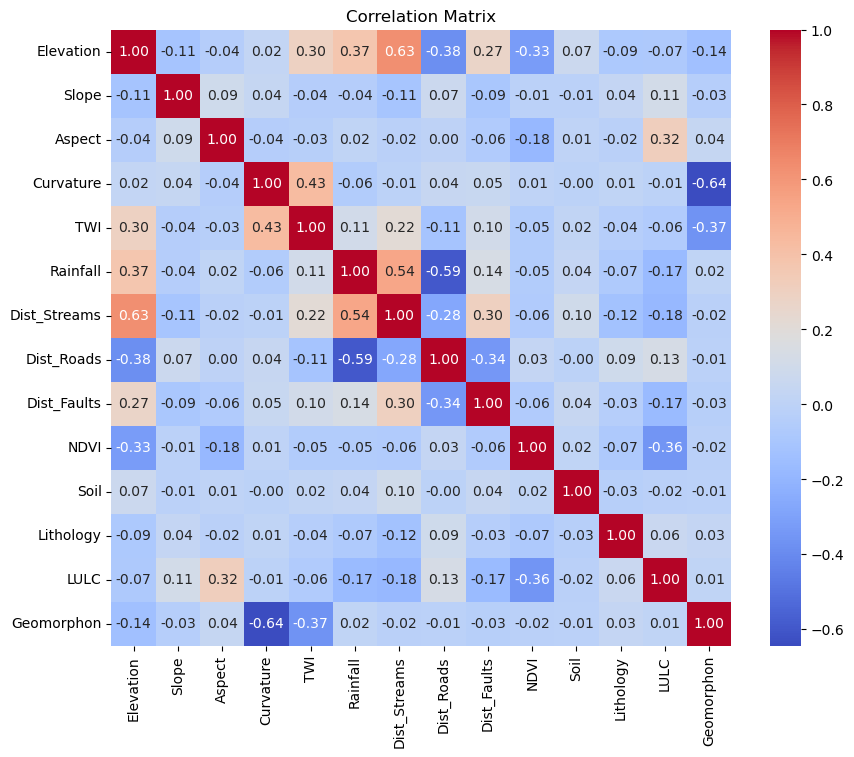

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [8]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 2. Select the 14 conditioning factors for the test
# List out your factors exactly as they appear in your dataframe
factors = [
    'Elevation', 'Slope', 'Aspect', 'Curvature', 'TWI', 
    'Geomorphon', 'Dist_Faults', 'Soil', 
    'Dist_Streams', 'Dist_Roads', 'NDVI', 'LULC', 'Rainfall', 'Lithology'
]

# 3. Pre-processing for VIF
# VIF requires a constant (intercept) to be added to the feature matrix
X = df[factors].dropna() # Ensure no NaN values exist in the 10m stack
X_with_const = add_constant(X)

# 4. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) 
                          for i in range(X_with_const.shape[1])]

# 5. Filter out the constant and sort by VIF
vif_result = vif_data[vif_data['Feature'] != 'const'].sort_values(by="VIF", ascending=False)

print("--- Multicollinearity Analysis Results ---")
print(vif_result)

# 6. Save results for your Dissertation Appendix
vif_result.to_csv('figures/vif_results_final.csv', index=False)

--- Multicollinearity Analysis Results ---
         Feature       VIF
9   Dist_Streams  2.457818
1      Elevation  2.407604
13      Rainfall  2.207543
10    Dist_Roads  1.997369
4      Curvature  1.927947
6     Geomorphon  1.813216
11          NDVI  1.450077
5            TWI  1.387728
12          LULC  1.366603
7    Dist_Faults  1.309477
3         Aspect  1.144647
2          Slope  1.037370
14     Lithology  1.033807
8           Soil  1.012959


In [6]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import StratifiedGroupKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, recall_score, precision_score, accuracy_score, f1_score

# ==========================================
# 1. LOAD DATA & FIX GROUPS
# ==========================================
df = pd.read_csv("Tehri_Landslide_Data.csv")

# Ensure every non-landslide point has a unique ID for grouping
mask = df['landslide_id'] == -1
max_id = df['landslide_id'].max()
df.loc[mask, 'landslide_id'] = np.arange(mask.sum()) + (max_id + 1)

bad_features = ['TRI', 'BSI']
features = [col for col in df.columns if col not in ['x', 'y', 'landslide_id', 'label'] + bad_features]

X = df[features]
y = df['label']
groups = df['landslide_id']

# ==========================================
# 2. DEFINE MODELS
# ==========================================
models = {
    'Logistic_Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random_Forest': RandomForestClassifier(n_estimators=500, max_depth=12, min_samples_leaf=5, n_jobs=-1, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.03, max_depth=6, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.03, max_depth=6, random_state=42, verbose=-1)
}

# ==========================================
# 3. CROSS-VALIDATION & PERFORMANCE TABLE
# ==========================================
# StratifiedGroupKFold prevents the "one class" ValueError and respects spatial groups
cv_strategy = StratifiedGroupKFold(n_splits=5)
performance_list = []

print(f"\nStarting Cross-Validation & Metric Calculation...")

for name, model in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('classifier', model)])
    
    # Generate Out-of-Fold predictions for the table
    y_pred_cv = cross_val_predict(pipe, X, y, groups=groups, cv=cv_strategy, method='predict')
    y_prob_cv = cross_val_predict(pipe, X, y, groups=groups, cv=cv_strategy, method='predict_proba')[:, 1]
    
    # Calculate Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y, y_pred_cv).ravel()
    
    # Calculate All Metrics
    performance_list.append({
        'Model': name,
        'TN': int(tn), 'FN': int(fn), 'FP': int(fp), 'TP': int(tp),
        'Sensitivity': round(recall_score(y, y_pred_cv), 2),
        'Specificity': round(tn / (tn + fp), 2),
        'Precision': round(precision_score(y, y_pred_cv), 2),
        'Accuracy': round(accuracy_score(y, y_pred_cv), 2),
        'F1-score': round(f1_score(y, y_pred_cv), 2),
        'AUC (%)': round(roc_auc_score(y, y_prob_cv) * 100, 2)
    })
    print(f"Completed metrics for: {name}")

# Create Performance Table
perf_df = pd.DataFrame(performance_list).set_index('Model').T
print("\n--- PREDICTIVE PERFORMANCE OF LANDSLIDE MODELS (CV VALIDATED) ---")
print(perf_df)

# ==========================================
# 4. SAVE MODELS & EXPORT TABLE
# ==========================================
output_dir = r"D:\landslide\models"
os.makedirs(output_dir, exist_ok=True)

perf_df.to_csv(os.path.join(output_dir, "Performance_Table_CV.csv"))

print("\nFinalizing and saving models...")
for name, model in models.items():
    full_pipe = Pipeline([('scaler', StandardScaler()), ('classifier', model)])
    full_pipe.fit(X, y)
    joblib.dump(full_pipe, os.path.join(output_dir, f"Tehri_LSM_{name}.pkl"))

print(f"All models and the performance table saved to {output_dir}")


Starting Cross-Validation & Metric Calculation...
Completed metrics for: Logistic_Regression
Completed metrics for: Random_Forest
Completed metrics for: XGBoost


c:\Users\sangh\anaconda3\envs\football\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\sangh\anaconda3\envs\football\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\sangh\anaconda3\envs\football\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\sangh\anaconda3\envs\football\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\sangh\anaconda3\envs\football\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

Completed metrics for: LightGBM

--- PREDICTIVE PERFORMANCE OF LANDSLIDE MODELS (CV VALIDATED) ---
Model        Logistic_Regression  Random_Forest  XGBoost  LightGBM
TN                       1974.00        2105.00  2124.00   2122.00
FN                        523.00         422.00   412.00    406.00
FP                        617.00         486.00   467.00    469.00
TP                       2068.00        2169.00  2179.00   2185.00
Sensitivity                 0.80           0.84     0.84      0.84
Specificity                 0.76           0.81     0.82      0.82
Precision                   0.77           0.82     0.82      0.82
Accuracy                    0.78           0.82     0.83      0.83
F1-score                    0.78           0.83     0.83      0.83
AUC (%)                    86.44          90.43    91.29     91.16

Finalizing and saving models...
All models and the performance table saved to D:\landslide\models


Generating Feature Importance Plots...


C:\Users\sangh\AppData\Local\Temp\ipykernel_2564\4100030371.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Value', y='Feature', data=feat_imp, ax=axes[i], palette='viridis')
C:\Users\sangh\AppData\Local\Temp\ipykernel_2564\4100030371.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Value', y='Feature', data=feat_imp, ax=axes[i], palette='viridis')
C:\Users\sangh\AppData\Local\Temp\ipykernel_2564\4100030371.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Value', y='Feature', data=feat_imp, ax=axes[i], palette='viridis'

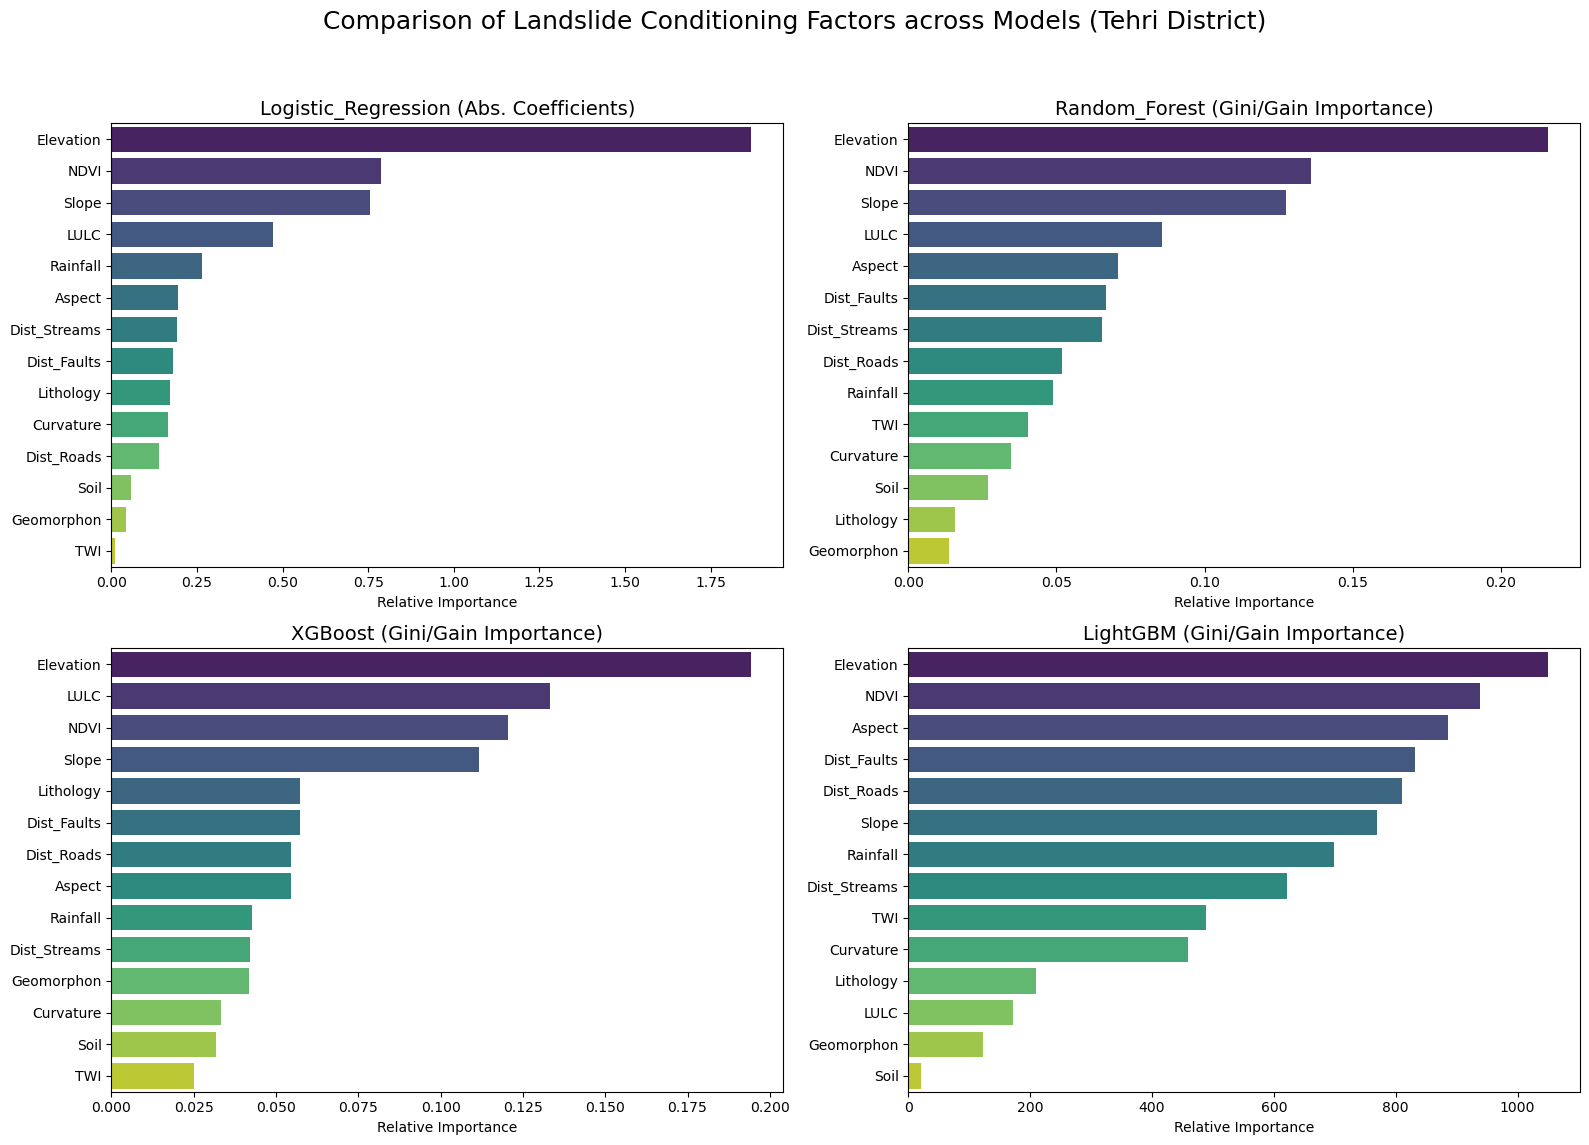

Comparison plot saved to D:\landslide\models


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os


df = pd.read_csv("Tehri_Landslide_Data.csv")
# 1. SETUP
model_dir = r"D:\landslide\models"
model_names = ['Logistic_Regression', 'Random_Forest', 'XGBoost', 'LightGBM']

# Define the features exactly as they were in the training X
# (Ensure this list matches the columns in your X from the previous step)
features = [col for col in df.columns if col not in ['x', 'y', 'landslide_id', 'label', 'TRI', 'BSI']]

# 2. CREATE PLOTTING GRID
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

print("Generating Feature Importance Plots...")

for i, name in enumerate(model_names):
    model_path = os.path.join(model_dir, f"Tehri_LSM_{name}.pkl")
    model_pipe = joblib.load(model_path)
    
    # Extract importance/coefficients
    if name == 'Logistic_Regression':
        # For Logistic, we use absolute coefficients
        importance = np.abs(model_pipe.named_steps['classifier'].coef_[0])
        title_suffix = "(Abs. Coefficients)"
    else:
        # For Trees (RF, XGB, LGBM), we use feature_importances_
        importance = model_pipe.named_steps['classifier'].feature_importances_
        title_suffix = "(Gini/Gain Importance)"

    # Create DataFrame for plotting
    feat_imp = pd.DataFrame({'Feature': features, 'Value': importance})
    feat_imp = feat_imp.sort_values(by='Value', ascending=False)

    # Plot
    sns.barplot(x='Value', y='Feature', data=feat_imp, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{name} {title_suffix}', fontsize=14)
    axes[i].set_xlabel('Relative Importance')
    axes[i].set_ylabel('')

plt.suptitle('Comparison of Landslide Conditioning Factors across Models (Tehri District)', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(model_dir, "Feature_Importance_Comparison.png"), dpi=300)
plt.show()

print(f"Comparison plot saved to {model_dir}")

In [2]:
import pandas as pd
import numpy as np
import joblib
import os
import jenkspy 

# 1. SETUP
# Ensure this CSV contains the 14 factors for ALL pixels in Tehri Garhwal
full_grid_df = pd.read_csv("Tehri_Landslide_Data.csv") 
model_dir = r"D:\landslide\models"
model_names = ['Logistic_Regression', 'Random_Forest', 'XGBoost', 'LightGBM']

# Feature list (must match your importance plot list)
features = [col for col in full_grid_df.columns if col not in ['x', 'y', 'landslide_id', 'label', 'TRI', 'BSI']]

results_summary = []

print("Calculating Area Distribution Percentages...")

for name in model_names:
    model_path = os.path.join(model_dir, f"Tehri_LSM_{name}.pkl")
    model_pipe = joblib.load(model_path)
    
    # Generate Probability (LSI)
    lsi_values = model_pipe.predict_proba(full_grid_df[features])[:, 1]
    full_grid_df[f'LSI_{name}'] = lsi_values
    
    # 2. APPLY NATURAL BREAKS (JENKS) - Updated Argument Name
    # We convert to list to avoid potential Series indexing issues
    breaks = jenkspy.jenks_breaks(lsi_values.tolist(), n_classes=5)
    labels = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
    
    full_grid_df[f'LSZ_{name}'] = pd.cut(
        full_grid_df[f'LSI_{name}'], 
        bins=breaks, 
        labels=labels, 
        include_lowest=True
    )
    
    # 3. CALCULATE PERCENTAGES
    area_dist = full_grid_df[f'LSZ_{name}'].value_counts(normalize=True).sort_index() * 100
    results_summary.append(area_dist.rename(name))

# 4. CONSOLIDATE RESULTS (For your Figure 7 Table)
final_area_table = pd.concat(results_summary, axis=1)
print("\n--- Final Area Distribution (%) for Figure 7 ---")
print(final_area_table)

# Export for your Records
final_area_table.to_csv(os.path.join(model_dir, "Area_Distribution_Results.csv"))

Calculating Area Distribution Percentages...


c:\Users\sangh\anaconda3\envs\football\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- Final Area Distribution (%) for Figure 7 ---
           Logistic_Regression  Random_Forest    XGBoost   LightGBM
Very Low             24.314936      25.858742  31.686607  30.084909
Low                  16.480124      16.345041  12.389039  12.504824
Moderate             15.283674      13.450405  10.401389  10.652258
High                 20.204554      18.969510  15.438055  15.264377
Very High            23.716712      25.376303  30.084909  31.493632


In [3]:
import pandas as pd
import numpy as np
import joblib
import os

# 1. SETUP
# This CSV should contain the features for your 2,661 landslide locations
landslide_inventory = pd.read_csv("Tehri_Landslide_Data.csv")
model_dir = r"D:\landslide\models"
model_names = ['Logistic_Regression', 'Random_Forest', 'XGBoost', 'LightGBM']

# Ensure features list matches your training/area distribution code
features = [col for col in landslide_inventory.columns if col not in ['x', 'y', 'landslide_id', 'label', 'TRI', 'BSI']]

nls_summary = []

print("Calculating Landslide Density per Susceptibility Zone...")

for name in model_names:
    model_path = os.path.join(model_dir, f"Tehri_LSM_{name}.pkl")
    model_pipe = joblib.load(model_path)
    
    # Generate Probability for the 2,661 landslide points
    probs = model_pipe.predict_proba(landslide_inventory[features])[:, 1]
    
    # 2. LOAD PREVIOUSLY DEFINED JENKS BREAKS
    # IMPORTANT: You must use the same 'breaks' calculated in the Area Distribution step
    # Load the Area Distribution Results to get those thresholds, or recalculate them
    # For this example, we assume 'breaks' are available from your previous script run
    labels = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
    
    # Assign each landslide point to a susceptibility class
    landslide_inventory[f'LSZ_{name}'] = pd.cut(
        probs, 
        bins=breaks, # Use the global 'breaks' list from the Jenks analysis
        labels=labels, 
        include_lowest=True
    )
    
    # 3. COUNT LANDSLIDES PER ZONE (nLs)
    nls_counts = landslide_inventory[f'LSZ_{name}'].value_counts().sort_index()
    nls_summary.append(nls_counts.rename(name))

# 4. CONSOLIDATE RESULTS (For your Figure 8 Table)
final_nls_table = pd.concat(nls_summary, axis=1)

print("\n--- Landslide Counts (nLs) for Figure 8 ---")
print(final_nls_table)

# Calculate Percentage captured in High + Very High for each model
for name in model_names:
    high_vhigh = final_nls_table.loc[['High', 'Very High'], name].sum()
    percentage = (high_vhigh / 2661) * 100
    print(f"{name}: Captures {high_vhigh} landslides ({percentage:.2f}%) in High/Very High zones.")

# Export results
final_nls_table.to_csv(os.path.join(model_dir, "Landslide_Density_Results.csv"))

Calculating Landslide Density per Susceptibility Zone...

--- Landslide Counts (nLs) for Figure 8 ---
           Logistic_Regression  Random_Forest  XGBoost  LightGBM
Very Low                  1044           1179     1612      1559
Low                        911            935      616       648
Moderate                   922            736      494       552
High                      1173           1072      785       791
Very High                 1105           1260     1667      1632
Logistic_Regression: Captures 2278 landslides (85.61%) in High/Very High zones.
Random_Forest: Captures 2332 landslides (87.64%) in High/Very High zones.
XGBoost: Captures 2452 landslides (92.15%) in High/Very High zones.
LightGBM: Captures 2423 landslides (91.06%) in High/Very High zones.


c:\Users\sangh\anaconda3\envs\football\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Generating ROC Curves via Stratified Cross-Validation...


c:\Users\sangh\anaconda3\envs\football\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\sangh\anaconda3\envs\football\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\sangh\anaconda3\envs\football\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\sangh\anaconda3\envs\football\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\sangh\anaconda3\envs\football\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

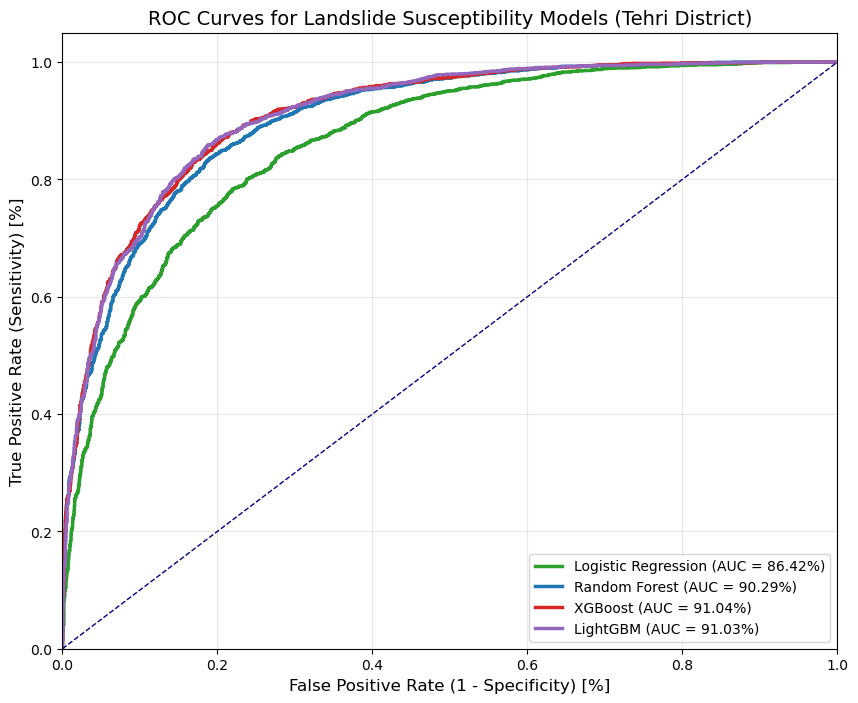

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 1. RE-PREPARE DATA
df = pd.read_csv("Tehri_Landslide_Data.csv")
bad_features = ['TRI', 'BSI']
features = [col for col in df.columns if col not in ['x', 'y', 'landslide_id', 'label'] + bad_features]

X = df[features]
y = df['label']

# 2. UPDATED CROSS-VALIDATION STRATEGY
# Using StratifiedKFold ensures every fold has a mix of 0s and 1s, 
# preventing the "at least 2 classes" ValueError.
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic_Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random_Forest': RandomForestClassifier(n_estimators=500, max_depth=12, min_samples_leaf=5, n_jobs=-1, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.03, max_depth=6, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.03, max_depth=6, random_state=42, verbose=-1)
}

output_dir = r"D:\landslide\models"
os.makedirs(output_dir, exist_ok=True)

# 3. GENERATE ROC CURVES
plt.figure(figsize=(10, 8))
colors = ['#2ca02c', '#1f77b4', '#d62728', '#9467bd']

print("Generating ROC Curves via Stratified Cross-Validation...")

for i, (name, model_obj) in enumerate(models.items()):
    pipe = Pipeline([('scaler', StandardScaler()), ('classifier', model_obj)])
    
    # Generate Out-of-Fold probabilities
    # This approach treats each fold as a testing set for performance validation
    y_prob_cv = cross_val_predict(pipe, X, y, cv=cv_strategy, method='predict_proba')[:, 1]
    
    # Calculate ROC metrics as per Chauhan et al. (2025) logic
    fpr, tpr, _ = roc_curve(y, y_prob_cv)
    roc_auc = auc(fpr, tpr)
    
    # Plotting each model curve
    plt.plot(fpr, tpr, color=colors[i], lw=2.5, 
             label=f'{name.replace("_", " ")} (AUC = {roc_auc*100:.2f}%)')

# 4. FORMATTING (Mirroring Figure 9 in Chauhan et al. 2025)
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity) [%]', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity) [%]', fontsize=12)
plt.title('ROC Curves for Landslide Susceptibility Models (Tehri District)', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

# Save for the Results chapter
plt.savefig(os.path.join(output_dir, "ROC_Final_Validation.png"), dpi=300, bbox_inches='tight')
plt.show()